In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua

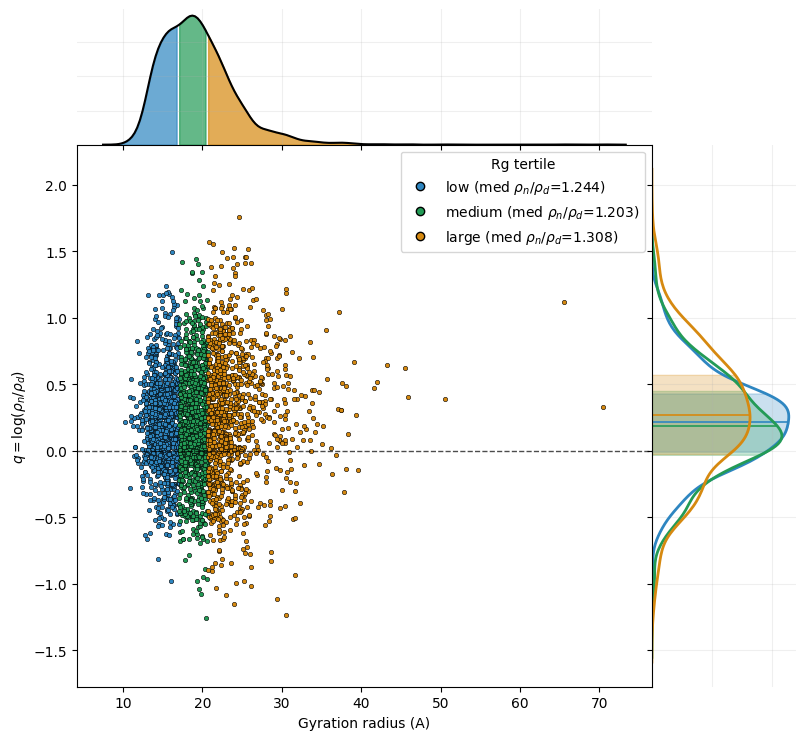

Numero complessi usati nel plot: 3134
Soglie terzili Rg (A): 17.051139311230344 20.66810326373692

Statistiche q per terzile (mediana e IQR):
               n    median       q25       q75
size_class                                    
low         1045  0.218671 -0.013091  0.440879
medium      1044  0.184540 -0.034871  0.466910
large       1045  0.268610 -0.025665  0.578088


In [2]:
from matplotlib.lines import Line2D

# Costruisce un dataset per complesso con valori native/decoy e calcola q = log(roughness_native / roughness_decoy)
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
 )

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df = pd.DataFrame(index=rough_pivot.index)
plot_df['roughness_native'] = rough_pivot.get('native')
plot_df['roughness_decoy'] = rough_pivot.get('decoy')
plot_df['gyration_radius_A'] = gyr_pivot.get('native')

# Fallback: se manca il raggio native, usa quello decoy
plot_df['gyration_radius_A'] = plot_df['gyration_radius_A'].fillna(gyr_pivot.get('decoy'))

plot_df = plot_df.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df = plot_df[(plot_df['roughness_native'] > 0) & (plot_df['roughness_decoy'] > 0)].copy()

plot_df['q'] = np.log(plot_df['roughness_native'] / plot_df['roughness_decoy'])

# Terzili del raggio di girazione
q1, q2 = plot_df['gyration_radius_A'].quantile([1/3, 2/3])
plot_df['size_class'] = pd.cut(
    plot_df['gyration_radius_A'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'medium', 'large']
 )

# Statistiche di q per terzile: mediana e IQR
q_stats = (
    plot_df.groupby('size_class', observed=False)['q']
    .agg(
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n='size'
    )
    .reindex(['low', 'medium', 'large'])
 )

tertile_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
marker_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
point_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}

g = sns.JointGrid(data=plot_df, x='gyration_radius_A', y='q', height=8, ratio=4, space=0)

# Marginale x: distribuzione totale del raggio di girazione (curva unica + riempimento a tratti per terzili)
sns.kdeplot(
    data=plot_df,
    x='gyration_radius_A',
    color='black',
    linewidth=1.5,
    ax=g.ax_marg_x
 )

x_line = g.ax_marg_x.lines[0]
x_data = x_line.get_xdata()
x_density = x_line.get_ydata()
x_order = np.argsort(x_data)
x_data = x_data[x_order]
x_density = x_density[x_order]

# Marginale y: distribuzioni di q per low / medium / large
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df.loc[plot_df['size_class'] == cls, 'q'].dropna()
    if cls_data.empty:
        continue
    sns.kdeplot(
        y=cls_data,
        ax=g.ax_marg_y,
        color=tertile_colors[cls],
        linewidth=2
    )
    y_line = g.ax_marg_y.lines[-1]
    y_data = y_line.get_ydata()
    y_density = y_line.get_xdata()
    med = q_stats.loc[cls, 'median']
    q25 = q_stats.loc[cls, 'q25']
    q75 = q_stats.loc[cls, 'q75']
    band_mask = (y_data >= q25) & (y_data <= q75)
    if np.any(band_mask):
        g.ax_marg_y.fill_betweenx(
            y_data[band_mask],
            0,
            y_density[band_mask],
            color=tertile_colors[cls],
            alpha=0.25
        )
    med_density = float(np.interp(med, y_data, y_density)) if len(y_data) > 1 else float(y_density[0])
    g.ax_marg_y.hlines(med, 0, med_density, color=tertile_colors[cls], linewidth=1.2)

# Sfondo colorato in 3 zone verticali (terzili di Rg)
xmin, xmax = plot_df['gyration_radius_A'].min(), plot_df['gyration_radius_A'].max()
#g.ax_joint.axvspan(xmin, q1, color=tertile_colors['low'], alpha=0.14)
#g.ax_joint.axvspan(q1, q2, color=tertile_colors['medium'], alpha=0.14)
#g.ax_joint.axvspan(q2, xmax, color=tertile_colors['large'], alpha=0.14)

# Riempie sotto la KDE del raggio per ciascun terzile
segment_bounds = [x_data.min(), q1, q2, x_data.max()]
for cls, left_bound, right_bound in zip(['low', 'medium', 'large'], segment_bounds[:-1], segment_bounds[1:]):
    segment_mask = (x_data >= left_bound) & (x_data <= right_bound)
    if not np.any(segment_mask):
        continue
    g.ax_marg_x.fill_between(
        x_data[segment_mask],
        0,
        x_density[segment_mask],
        color=tertile_colors[cls],
        alpha=0.7
    )

# Scatter centrale
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls]
    if cls_data.empty:
        continue
    sns.scatterplot(
        data=cls_data,
        x='gyration_radius_A',
        y='q',
        color=point_colors[cls],
        s=10,
        edgecolor='black',
        linewidth=0.4,
        ax=g.ax_joint,
        label=cls
    )

legend_handles = []
for cls in ['low', 'medium', 'large']:
    if cls not in q_stats.index or pd.isna(q_stats.loc[cls, 'median']):
        continue
    med = q_stats.loc[cls, 'median']
    med_ratio = np.exp(med)
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            color=tertile_colors[cls],
            markerfacecolor=marker_colors[cls],
            markeredgecolor='black',
            markersize=6,
            label=fr"{cls} (med $\rho_n/\rho_d$={med_ratio:.3f})"
        )
    )

g.ax_joint.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.set_xlabel('Gyration radius (A)')
g.ax_joint.set_ylabel(r'$q = \log(\rho_n/\rho_d)$')
g.ax_joint.set_title('q vs Gyration Radius with Tertile Regions (tot_df)')
g.ax_joint.legend(handles=legend_handles, title='Rg tertile')

g.ax_marg_x.set_ylabel('Density')
g.ax_marg_y.set_xlabel('Density')
g.ax_marg_x.grid(alpha=0.2)
g.ax_marg_y.grid(alpha=0.2)

g.fig.subplots_adjust(top=0.92)
plt.show()

print('Numero complessi usati nel plot:', len(plot_df))
print('Soglie terzili Rg (A):', float(q1), float(q2))
print('\nStatistiche q per terzile (mediana e IQR):')
print(q_stats[['n', 'median', 'q25', 'q75']])

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua

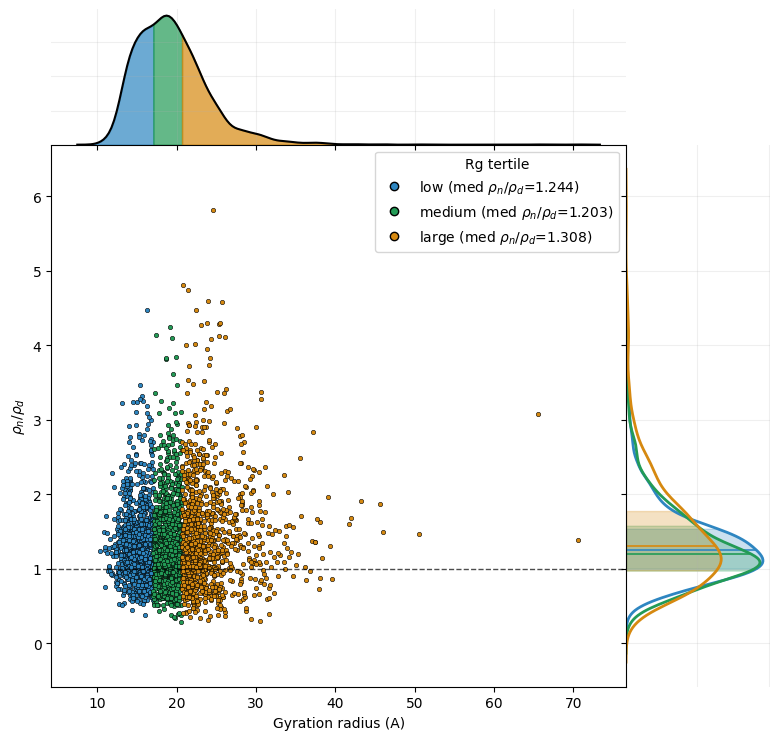

Numero complessi usati nel plot: 3134
Soglie terzili Rg (A): 17.051139311230344 20.66810326373692

Statistiche rho_n/rho_d per terzile (mediana e IQR):
               n    median       q25       q75
size_class                                    
low         1045  1.244422  0.986994  1.554072
medium      1044  1.202665  0.965730  1.595058
large       1045  1.308145  0.974662  1.782626


In [3]:
from matplotlib.lines import Line2D

# Versione della cella 2 con y = rho_n / rho_d al posto di q
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
)

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df = pd.DataFrame(index=rough_pivot.index)
plot_df['roughness_native'] = rough_pivot.get('native')
plot_df['roughness_decoy'] = rough_pivot.get('decoy')
plot_df['gyration_radius_A'] = gyr_pivot.get('native')

# Fallback: se manca il raggio native, usa quello decoy
plot_df['gyration_radius_A'] = plot_df['gyration_radius_A'].fillna(gyr_pivot.get('decoy'))

plot_df = plot_df.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df = plot_df[(plot_df['roughness_native'] > 0) & (plot_df['roughness_decoy'] > 0)].copy()

plot_df['rho_ratio'] = plot_df['roughness_native'] / plot_df['roughness_decoy']

# Terzili del raggio di girazione
q1, q2 = plot_df['gyration_radius_A'].quantile([1/3, 2/3])
plot_df['size_class'] = pd.cut(
    plot_df['gyration_radius_A'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'medium', 'large']
)

# Statistiche di rho_ratio per terzile: mediana e IQR
ratio_stats = (
    plot_df.groupby('size_class', observed=False)['rho_ratio']
    .agg(
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n='size'
    )
    .reindex(['low', 'medium', 'large'])
)

tertile_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
marker_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
point_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}

g = sns.JointGrid(data=plot_df, x='gyration_radius_A', y='rho_ratio', height=8, ratio=4, space=0)

# Marginale x: distribuzione totale del raggio di girazione (curva unica + riempimento a tratti per terzili)
sns.kdeplot(
    data=plot_df,
    x='gyration_radius_A',
    color='black',
    linewidth=1.5,
    ax=g.ax_marg_x
)

x_line = g.ax_marg_x.lines[0]
x_data = x_line.get_xdata()
x_density = x_line.get_ydata()
x_order = np.argsort(x_data)
x_data = x_data[x_order]
x_density = x_density[x_order]
xmin, xmax = float(x_data.min()), float(x_data.max())

# Riempie sotto la KDE del raggio di girazione per ciascun terzile
segment_bounds = [xmin, q1, q2, xmax]
for cls, left_bound, right_bound in zip(['low', 'medium', 'large'], segment_bounds[:-1], segment_bounds[1:]):
    segment_mask = (x_data >= left_bound) & (x_data <= right_bound)
    segment_x = x_data[segment_mask]
    segment_y = x_density[segment_mask]
    if segment_x.size == 0:
        segment_x = np.array([left_bound, right_bound])
        segment_y = np.interp(segment_x, x_data, x_density)
    else:
        if segment_x[0] > left_bound:
            segment_x = np.r_[left_bound, segment_x]
            segment_y = np.r_[np.interp(left_bound, x_data, x_density), segment_y]
        if segment_x[-1] < right_bound:
            segment_x = np.r_[segment_x, right_bound]
            segment_y = np.r_[segment_y, np.interp(right_bound, x_data, x_density)]
    g.ax_marg_x.fill_between(
        segment_x,
        0,
        segment_y,
        color=tertile_colors[cls],
        alpha=0.7,
        interpolate=True
    )

# Marginale y: distribuzioni di rho_n / rho_d per low / medium / large
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df.loc[plot_df['size_class'] == cls, 'rho_ratio'].dropna()
    if cls_data.empty:
        continue
    sns.kdeplot(
        y=cls_data,
        ax=g.ax_marg_y,
        color=tertile_colors[cls],
        linewidth=2
    )
    y_line = g.ax_marg_y.lines[-1]
    y_data = y_line.get_ydata()
    y_density = y_line.get_xdata()
    med = ratio_stats.loc[cls, 'median']
    q25 = ratio_stats.loc[cls, 'q25']
    q75 = ratio_stats.loc[cls, 'q75']
    band_mask = (y_data >= q25) & (y_data <= q75)
    if np.any(band_mask):
        g.ax_marg_y.fill_betweenx(
            y_data[band_mask],
            0,
            y_density[band_mask],
            color=tertile_colors[cls],
            alpha=0.25
        )
    med_density = float(np.interp(med, y_data, y_density)) if len(y_data) > 1 else float(y_density[0])
    g.ax_marg_y.hlines(med, 0, med_density, color=tertile_colors[cls], linewidth=1.2)

# Scatter centrale
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls]
    if cls_data.empty:
        continue
    sns.scatterplot(
        data=cls_data,
        x='gyration_radius_A',
        y='rho_ratio',
        color=point_colors[cls],
        s=10,
        edgecolor='black',
        linewidth=0.4,
        ax=g.ax_joint,
        label=cls
    )

legend_handles = []
for cls in ['low', 'medium', 'large']:
    if cls not in ratio_stats.index or pd.isna(ratio_stats.loc[cls, 'median']):
        continue
    med = ratio_stats.loc[cls, 'median']
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            color=tertile_colors[cls],
            markerfacecolor=marker_colors[cls],
            markeredgecolor='black',
            markersize=6,
            label=fr"{cls} (med $\rho_n/\rho_d$={med:.3f})"
        )
    )

g.ax_joint.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.set_xlabel('Gyration radius (A)')
g.ax_joint.set_ylabel(r'$\rho_n/\rho_d$')
g.ax_joint.set_title('rho_n/rho_d vs Gyration Radius with Tertile Regions (tot_df)')
g.ax_joint.legend(handles=legend_handles, title='Rg tertile')

g.ax_marg_x.set_ylabel('Density')
g.ax_marg_y.set_xlabel('Density')
g.ax_marg_x.grid(alpha=0.2)
g.ax_marg_y.grid(alpha=0.2)

g.fig.subplots_adjust(top=0.92)
plt.show()

print('Numero complessi usati nel plot:', len(plot_df))
print('Soglie terzili Rg (A):', float(q1), float(q2))
print('\nStatistiche rho_n/rho_d per terzile (mediana e IQR):')
print(ratio_stats[['n', 'median', 'q25', 'q75']])

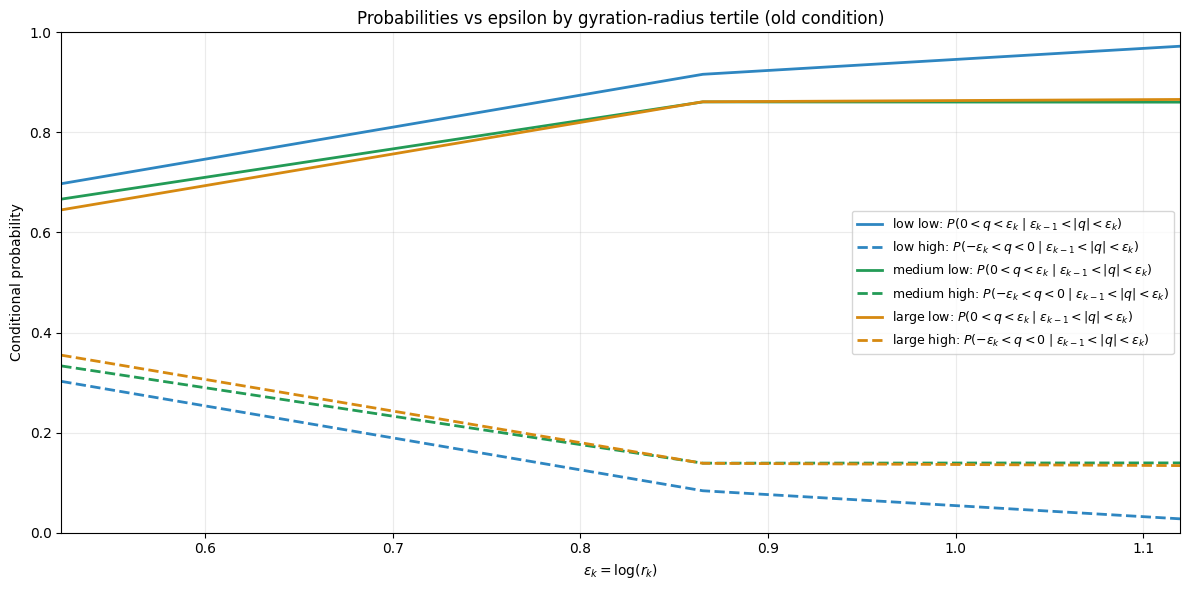

n scelto automaticamente: 3
min_bin_count richiesto per bin: 10
range ratio usato: 1.0 3.063185719523264


In [4]:
# 3 curve per terzile di Rg nello stesso grafico:
# P(0<q<epsilon_k | eps_{k-1}<|q|<eps_k) e P(-epsilon_k<q<0 | eps_{k-1}<|q|<eps_k)

# Scelgo n in modo automatico: il più grande possibile che garantisca abbastanza statistica in ogni bin.
# Gli intervalli sono equispaziati in rho_n/rho_d; sull'asse x uso epsilon_k = log(r_k)
paired_q = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
 )

rough_pivot_q = paired_q.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot_q = paired_q.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df_q = pd.DataFrame(index=rough_pivot_q.index)
plot_df_q['roughness_native'] = rough_pivot_q.get('native')
plot_df_q['roughness_decoy'] = rough_pivot_q.get('decoy')
plot_df_q['gyration_radius_A'] = gyr_pivot_q.get('native')
plot_df_q['gyration_radius_A'] = plot_df_q['gyration_radius_A'].fillna(gyr_pivot_q.get('decoy'))
plot_df_q = plot_df_q.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df_q = plot_df_q[(plot_df_q['roughness_native'] > 0) & (plot_df_q['roughness_decoy'] > 0)].copy()
plot_df_q['q'] = np.log(plot_df_q['roughness_native'] / plot_df_q['roughness_decoy'])

# Terzili del raggio di girazione
q1, q2 = plot_df_q['gyration_radius_A'].quantile([1/3, 2/3])
plot_df_q['size_class'] = pd.cut(
    plot_df_q['gyration_radius_A'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low', 'medium', 'large']
 )

abs_q = np.abs(plot_df_q['q'].dropna())
ratio_max = float(np.exp(abs_q.quantile(0.98)))
tertiles = ['low', 'medium', 'large']

min_bin_count = 10
max_n = 100
n_candidates = range(max_n, 1, -1)

for candidate_n in n_candidates:
    candidate_edges = np.linspace(1.0, ratio_max, candidate_n + 1)
    candidate_eps = np.log(candidate_edges[1:])
    valid_candidate = True

    for tertile in tertiles:
        q_vals = plot_df_q.loc[plot_df_q['size_class'] == tertile, 'q'].dropna().to_numpy()
        for idx, epsilon_k in enumerate(candidate_eps, start=1):
            epsilon_prev = np.log(candidate_edges[idx - 1])
            bin_mask = (np.abs(q_vals) > epsilon_prev) & (np.abs(q_vals) < epsilon_k)
            if bin_mask.sum() < min_bin_count:
                valid_candidate = False
                break
        if not valid_candidate:
            break

    if valid_candidate:
        n = candidate_n
        break

if n is None:
    n = 10

n=3

ratio_edges = np.linspace(1.0, ratio_max, n + 1)
epsilon_grid = np.log(ratio_edges[1:])

fig, ax = plt.subplots(figsize=(12, 6))

tertile_line_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}

for tertile in tertiles:
    q_vals = plot_df_q.loc[plot_df_q['size_class'] == tertile, 'q'].dropna().to_numpy()

    p_pos = []
    p_neg = []

    for idx, epsilon_k in enumerate(epsilon_grid, start=1):
        epsilon_prev = np.log(ratio_edges[idx - 1])
        cond = (np.abs(q_vals) > epsilon_prev) & (np.abs(q_vals) < epsilon_k)
        denom = cond.sum()

        if denom == 0:
            p_pos.append(np.nan)
            p_neg.append(np.nan)
            continue

        q_cond = q_vals[cond]
        p_pos.append(((q_cond > 0) & (q_cond < epsilon_k)).sum() / denom)
        p_neg.append(((q_cond < 0) & (q_cond > -epsilon_k)).sum() / denom)

    p_pos = np.asarray(p_pos, dtype=float)
    p_neg = np.asarray(p_neg, dtype=float)

    diff = p_pos - p_neg
    valid = np.isfinite(diff)
    intersection_eps = np.nan

    if np.count_nonzero(valid) >= 2:
        valid_idx = np.flatnonzero(valid)
        for left_idx, right_idx in zip(valid_idx[:-1], valid_idx[1:]):
            left_diff = diff[left_idx]
            right_diff = diff[right_idx]
            if left_diff == 0:
                intersection_eps = epsilon_grid[left_idx]
            elif left_diff * right_diff < 0:
                x0 = epsilon_grid[left_idx]
                x1 = epsilon_grid[right_idx]
                intersection_eps = x0 + (0 - left_diff) * (x1 - x0) / (right_diff - left_diff)
            if not np.isnan(intersection_eps):
                break

    ax.plot(
        epsilon_grid,
        p_pos,
        color=tertile_line_colors[tertile],
        lw=2,
        label=fr'{tertile} low: $P(0<q<\epsilon_k\mid \epsilon_{{k-1}}<|q|<\epsilon_k)$'
    )
    ax.plot(
        epsilon_grid,
        p_neg,
        color=tertile_line_colors[tertile],
        lw=2,
        linestyle='--',
        label=fr'{tertile} high: $P(-\epsilon_k<q<0\mid \epsilon_{{k-1}}<|q|<\epsilon_k)$'
    )

    if not np.isnan(intersection_eps):
        ax.axvline(intersection_eps, color=tertile_line_colors[tertile], linestyle=':', alpha=0.7)

ax.set_title('Probabilities vs epsilon by gyration-radius tertile (old condition)')
ax.set_xlabel(r'$\epsilon_k = \log(r_k)$')
ax.set_ylabel('Conditional probability')
ax.set_xlim(epsilon_grid.min(), epsilon_grid.max())
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

print('n scelto automaticamente:', n)
print('min_bin_count richiesto per bin:', min_bin_count)
print('range ratio usato:', 1.0, ratio_max)

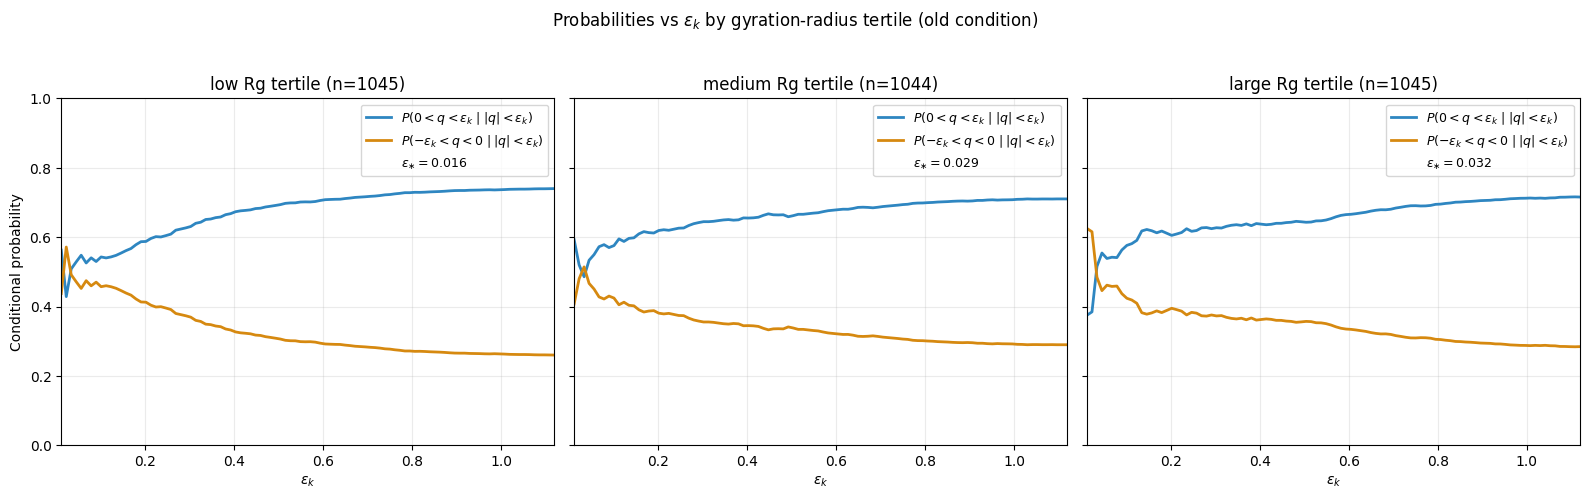

Numero complessi usati nel plot: 3134
Soglie terzili Rg (A): 17.051139311230344 20.66810326373692


In [5]:
from matplotlib.lines import Line2D

# 3 subplot (uno per terzile di Rg) con la vecchia condizione:
# P(0<q<epsilon_k | |q|<epsilon_k) e P(-epsilon_k<q<0 | |q|<epsilon_k)

paired_q = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
 )

rough_pivot_q = paired_q.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot_q = paired_q.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df_q = pd.DataFrame(index=rough_pivot_q.index)
plot_df_q['roughness_native'] = rough_pivot_q.get('native')
plot_df_q['roughness_decoy'] = rough_pivot_q.get('decoy')
plot_df_q['gyration_radius_A'] = gyr_pivot_q.get('native')

# Fallback: se manca il raggio native, usa quello decoy
plot_df_q['gyration_radius_A'] = plot_df_q['gyration_radius_A'].fillna(gyr_pivot_q.get('decoy'))

plot_df_q = plot_df_q.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df_q = plot_df_q[(plot_df_q['roughness_native'] > 0) & (plot_df_q['roughness_decoy'] > 0)].copy()
plot_df_q['q'] = np.log(plot_df_q['roughness_native'] / plot_df_q['roughness_decoy'])

# Terzili del raggio di girazione
q_low, q_high = plot_df_q['gyration_radius_A'].quantile([1/3, 2/3])
plot_df_q['size_class'] = pd.cut(
    plot_df_q['gyration_radius_A'],
    bins=[-np.inf, q_low, q_high, np.inf],
    labels=['low', 'medium', 'large']
 )

abs_q = np.abs(plot_df_q['q'].dropna())
epsilon_max = float(abs_q.quantile(0.98))
n = 100
epsilon_grid = np.linspace(epsilon_max / n, epsilon_max, n)

tertiles = ['low', 'medium', 'large']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

for ax, tertile in zip(axes, tertiles):
    q_vals = plot_df_q.loc[plot_df_q['size_class'] == tertile, 'q'].dropna().to_numpy()

    p_pos = []
    p_neg = []

    for epsilon_k in epsilon_grid:
        cond = np.abs(q_vals) < epsilon_k
        denom = cond.sum()

        if denom == 0:
            p_pos.append(np.nan)
            p_neg.append(np.nan)
            continue

        q_cond = q_vals[cond]
        p_pos.append(((q_cond > 0) & (q_cond < epsilon_k)).sum() / denom)
        p_neg.append(((q_cond < 0) & (q_cond > -epsilon_k)).sum() / denom)

    p_pos = np.asarray(p_pos, dtype=float)
    p_neg = np.asarray(p_neg, dtype=float)

    diff = p_pos - p_neg
    valid = np.isfinite(diff)
    intersection_eps = np.nan

    if np.count_nonzero(valid) >= 2:
        valid_idx = np.flatnonzero(valid)
        for left_idx, right_idx in zip(valid_idx[:-1], valid_idx[1:]):
            left_diff = diff[left_idx]
            right_diff = diff[right_idx]
            if left_diff == 0:
                intersection_eps = epsilon_grid[left_idx]
            elif left_diff * right_diff < 0:
                x0 = epsilon_grid[left_idx]
                x1 = epsilon_grid[right_idx]
                intersection_eps = x0 + (0 - left_diff) * (x1 - x0) / (right_diff - left_diff)
            if not np.isnan(intersection_eps):
                break

    ax.plot(epsilon_grid, p_pos, color='#2e86c1', lw=2, label=r'$P(0<q<\epsilon_k\mid |q|<\epsilon_k)$')
    ax.plot(epsilon_grid, p_neg, color='#d68910', lw=2, label=r'$P(-\epsilon_k<q<0\mid |q|<\epsilon_k)$')

    ax.set_title(f'{tertile} Rg tertile (n={len(q_vals)})')
    ax.set_xlabel(r'$\epsilon_k$')
    ax.set_xlim(epsilon_grid.min(), epsilon_grid.max())
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)

    legend_handles = list(ax.get_lines()[:2])
    if not np.isnan(intersection_eps):
        legend_handles.append(
            Line2D([], [], linestyle='none', marker='', label=fr'$\epsilon_{{\ast}}={intersection_eps:.3f}$')
        )

    ax.legend(handles=legend_handles, loc='best', fontsize=9)

axes[0].set_ylabel('Conditional probability')
plt.suptitle(r'Probabilities vs $\epsilon_k$ by gyration-radius tertile (old condition)', y=1.03)
plt.tight_layout()
plt.show()

print('Numero complessi usati nel plot:', len(plot_df_q))
print('Soglie terzili Rg (A):', float(q_low), float(q_high))

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua

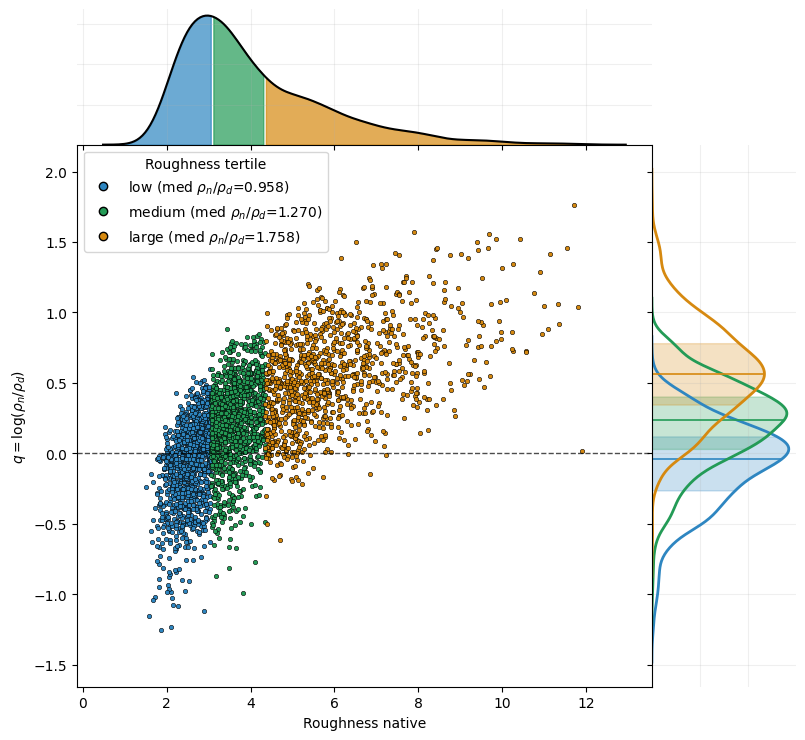

Numero complessi usati nel plot: 3134
Soglie terzili roughness native: 3.0547927303499818 4.351447539876785

Statistiche q per terzile (mediana e IQR):
               n    median       q25       q75
size_class                                    
low         1045 -0.043149 -0.273865  0.128220
medium      1044  0.239265  0.030903  0.410786
large       1045  0.564113  0.335360  0.795806


In [6]:
from matplotlib.lines import Line2D

# Versione della cella q con asse x = roughness native
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
 )

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df = pd.DataFrame(index=rough_pivot.index)
plot_df['roughness_native'] = rough_pivot.get('native')
plot_df['roughness_decoy'] = rough_pivot.get('decoy')
plot_df['gyration_radius_A'] = gyr_pivot.get('native')

# Fallback: se manca il raggio native, usa quello decoy
plot_df['gyration_radius_A'] = plot_df['gyration_radius_A'].fillna(gyr_pivot.get('decoy'))

plot_df = plot_df.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df = plot_df[(plot_df['roughness_native'] > 0) & (plot_df['roughness_decoy'] > 0)].copy()

plot_df['q'] = np.log(plot_df['roughness_native'] / plot_df['roughness_decoy'])

# Terzili della roughness native
x_low, x_high = plot_df['roughness_native'].quantile([1/3, 2/3])
plot_df['size_class'] = pd.cut(
    plot_df['roughness_native'],
    bins=[-np.inf, x_low, x_high, np.inf],
    labels=['low', 'medium', 'large']
 )

# Statistiche di q per terzile: mediana e IQR
q_stats = (
    plot_df.groupby('size_class', observed=False)['q']
    .agg(
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n='size'
    )
    .reindex(['low', 'medium', 'large'])
 )

tertile_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
marker_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
point_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}

g = sns.JointGrid(data=plot_df, x='roughness_native', y='q', height=8, ratio=4, space=0)

# Marginale x: distribuzione totale della roughness native (curva unica + riempimento a tratti per terzili)
sns.kdeplot(
    data=plot_df,
    x='roughness_native',
    color='black',
    linewidth=1.5,
    ax=g.ax_marg_x
 )

x_line = g.ax_marg_x.lines[0]
x_data = x_line.get_xdata()
x_density = x_line.get_ydata()

# Riempie sotto la KDE della roughness native per ciascun terzile
xmin, xmax = float(x_data.min()), float(x_data.max())
segment_bounds = [xmin, x_low, x_high, xmax]
for cls, left_bound, right_bound in zip(['low', 'medium', 'large'], segment_bounds[:-1], segment_bounds[1:]):
    segment_mask = (x_data >= left_bound) & (x_data <= right_bound)
    if not np.any(segment_mask):
        continue
    g.ax_marg_x.fill_between(
        x_data[segment_mask],
        0,
        x_density[segment_mask],
        color=tertile_colors[cls],
        alpha=0.7
    )

# Marginale y: distribuzioni di q per low / medium / large
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df.loc[plot_df['size_class'] == cls, 'q'].dropna()
    if cls_data.empty:
        continue
    sns.kdeplot(
        y=cls_data,
        ax=g.ax_marg_y,
        color=tertile_colors[cls],
        linewidth=2
    )
    y_line = g.ax_marg_y.lines[-1]
    y_data = y_line.get_ydata()
    y_density = y_line.get_xdata()
    med = q_stats.loc[cls, 'median']
    q25 = q_stats.loc[cls, 'q25']
    q75 = q_stats.loc[cls, 'q75']
    band_mask = (y_data >= q25) & (y_data <= q75)
    if np.any(band_mask):
        g.ax_marg_y.fill_betweenx(
            y_data[band_mask],
            0,
            y_density[band_mask],
            color=tertile_colors[cls],
            alpha=0.25
        )
    med_density = float(np.interp(med, y_data, y_density)) if len(y_data) > 1 else float(y_density[0])
    g.ax_marg_y.hlines(med, 0, med_density, color=tertile_colors[cls], linewidth=1.2)

# Scatter centrale
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls]
    if cls_data.empty:
        continue
    sns.scatterplot(
        data=cls_data,
        x='roughness_native',
        y='q',
        color=point_colors[cls],
        s=10,
        edgecolor='black',
        linewidth=0.4,
        ax=g.ax_joint,
        label=cls
    )

legend_handles = []
for cls in ['low', 'medium', 'large']:
    if cls not in q_stats.index or pd.isna(q_stats.loc[cls, 'median']):
        continue
    med = q_stats.loc[cls, 'median']
    med_ratio = np.exp(med)
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            color=tertile_colors[cls],
            markerfacecolor=marker_colors[cls],
            markeredgecolor='black',
            markersize=6,
            label=fr"{cls} (med $\rho_n/\rho_d$={med_ratio:.3f})"
        )
    )

g.ax_joint.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.set_xlabel('Roughness native')
g.ax_joint.set_ylabel(r'$q = \log(\rho_n/\rho_d)$')
g.ax_joint.set_title('q vs Roughness native with Tertile Regions (tot_df)')
g.ax_joint.legend(handles=legend_handles, title='Roughness tertile')

g.ax_marg_x.set_ylabel('Density')
g.ax_marg_y.set_xlabel('Density')
g.ax_marg_x.grid(alpha=0.2)
g.ax_marg_y.grid(alpha=0.2)

g.fig.subplots_adjust(top=0.92)
plt.show()

print('Numero complessi usati nel plot:', len(plot_df))
print('Soglie terzili roughness native:', float(x_low), float(x_high))
print('\nStatistiche q per terzile (mediana e IQR):')
print(q_stats[['n', 'median', 'q25', 'q75']])

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua

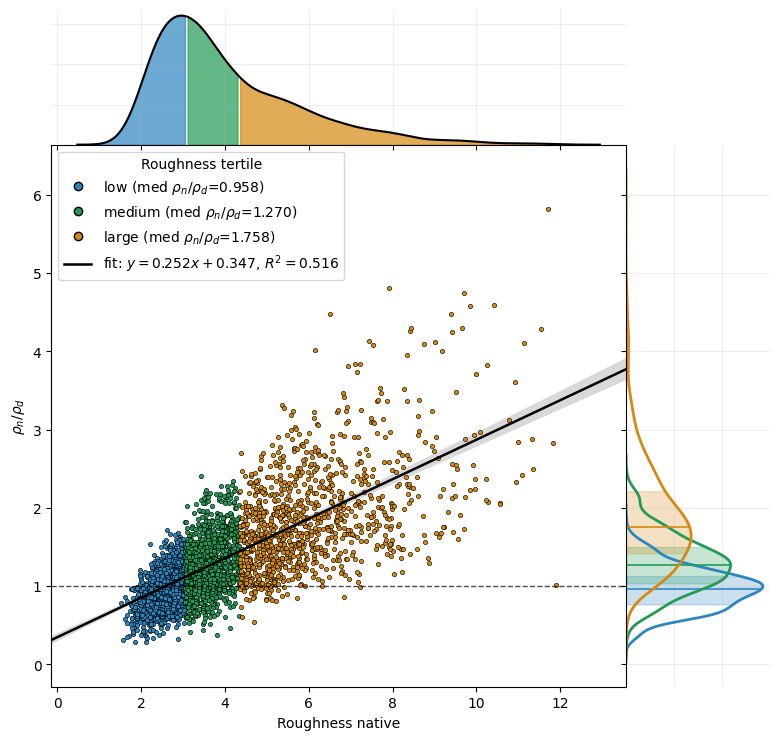

Numero complessi usati nel plot: 3134
Soglie terzili roughness native: 3.0547927303499818 4.351447539876785

Conteggio complessi rispetto alla retta del fit per terzile:
low: sopra=493, sotto=552, uguali=0
medium: sopra=538, sotto=506, uguali=0
large: sopra=455, sotto=590, uguali=0

Statistiche rho_n/rho_d per terzile (mediana e IQR):
               n    median       q25       q75
size_class                                    
low         1045  0.957769  0.760435  1.136803
medium      1044  1.270316  1.031385  1.508002
large       1045  1.757888  1.398443  2.216226


In [7]:
from matplotlib.lines import Line2D

# Versione della cella rho_n / rho_d con asse x = roughness native
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness', 'gyration_radius']]
    .mean()
 )

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')
gyr_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='gyration_radius')

plot_df = pd.DataFrame(index=rough_pivot.index)
plot_df['roughness_native'] = rough_pivot.get('native')
plot_df['roughness_decoy'] = rough_pivot.get('decoy')
plot_df['gyration_radius_A'] = gyr_pivot.get('native')

# Fallback: se manca il raggio native, usa quello decoy
plot_df['gyration_radius_A'] = plot_df['gyration_radius_A'].fillna(gyr_pivot.get('decoy'))

plot_df = plot_df.dropna(subset=['roughness_native', 'roughness_decoy', 'gyration_radius_A']).copy()
plot_df = plot_df[(plot_df['roughness_native'] > 0) & (plot_df['roughness_decoy'] > 0)].copy()

plot_df['rho_ratio'] = plot_df['roughness_native'] / plot_df['roughness_decoy']

# Terzili della roughness native
x_low, x_high = plot_df['roughness_native'].quantile([1/3, 2/3])
plot_df['size_class'] = pd.cut(
    plot_df['roughness_native'],
    bins=[-np.inf, x_low, x_high, np.inf],
    labels=['low', 'medium', 'large']
 )

# Statistiche di rho_ratio per terzile: mediana e IQR
ratio_stats = (
    plot_df.groupby('size_class', observed=False)['rho_ratio']
    .agg(
        median='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n='size'
    )
    .reindex(['low', 'medium', 'large'])
 )

tertile_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
marker_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}
point_colors = {'low': '#2e86c1', 'medium': '#239b56', 'large': '#d68910'}

g = sns.JointGrid(data=plot_df, x='roughness_native', y='rho_ratio', height=8, ratio=4, space=0)

# Marginale x: distribuzione totale della roughness native (curva unica + riempimento a tratti per terzili)
sns.kdeplot(
    data=plot_df,
    x='roughness_native',
    color='black',
    linewidth=1.5,
    ax=g.ax_marg_x
 )

x_line = g.ax_marg_x.lines[0]
x_data = x_line.get_xdata()
x_density = x_line.get_ydata()

# Riempie sotto la KDE della roughness native per ciascun terzile
xmin, xmax = x_data.min(), x_data.max()
segment_bounds = [xmin, x_low, x_high, xmax]
for cls, left_bound, right_bound in zip(['low', 'medium', 'large'], segment_bounds[:-1], segment_bounds[1:]):
    segment_mask = (x_data >= left_bound) & (x_data <= right_bound)
    if not np.any(segment_mask):
        continue
    g.ax_marg_x.fill_between(
        x_data[segment_mask],
        0,
        x_density[segment_mask],
        color=tertile_colors[cls],
        alpha=0.7
    )

# Marginale y: distribuzioni di rho_n / rho_d per low / medium / large
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df.loc[plot_df['size_class'] == cls, 'rho_ratio'].dropna()
    if cls_data.empty:
        continue
    sns.kdeplot(
        y=cls_data,
        ax=g.ax_marg_y,
        color=tertile_colors[cls],
        linewidth=2
    )
    y_line = g.ax_marg_y.lines[-1]
    y_data = y_line.get_ydata()
    y_density = y_line.get_xdata()
    med = ratio_stats.loc[cls, 'median']
    q25 = ratio_stats.loc[cls, 'q25']
    q75 = ratio_stats.loc[cls, 'q75']
    band_mask = (y_data >= q25) & (y_data <= q75)
    if np.any(band_mask):
        g.ax_marg_y.fill_betweenx(
            y_data[band_mask],
            0,
            y_density[band_mask],
            color=tertile_colors[cls],
            alpha=0.25
        )
    med_density = np.interp(med, y_data, y_density)
    g.ax_marg_y.hlines(med, 0, med_density, color=tertile_colors[cls], linewidth=1.2)

# Regressione lineare centrale su tutti i punti
sns.regplot(
    data=plot_df,
    x='roughness_native',
    y='rho_ratio',
    ax=g.ax_joint,
    scatter=False,
    line_kws={'color': 'black', 'linewidth': 1.8},
    truncate=False
 )

slope, intercept = np.polyfit(plot_df['roughness_native'], plot_df['rho_ratio'], 1)
r_value = np.corrcoef(plot_df['roughness_native'], plot_df['rho_ratio'])[0, 1]
r_squared = r_value ** 2

# Conteggio dei punti sopra/sotto la retta del fit per ciascun terzile
fit_counts = {}
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls].copy()
    if cls_data.empty:
        continue
    y_fit = slope * cls_data['roughness_native'] + intercept
    above = int((cls_data['rho_ratio'] > y_fit).sum())
    below = int((cls_data['rho_ratio'] < y_fit).sum())
    equal = int((cls_data['rho_ratio'] == y_fit).sum())
    fit_counts[cls] = {'above': above, 'below': below, 'equal': equal}

# Punti colorati per terzile, come prima
for cls in ['low', 'medium', 'large']:
    cls_data = plot_df[plot_df['size_class'] == cls]
    if cls_data.empty:
        continue
    sns.scatterplot(
        data=cls_data,
        x='roughness_native',
        y='rho_ratio',
        color=point_colors[cls],
        s=10,
        edgecolor='black',
        linewidth=0.4,
        ax=g.ax_joint,
        label=cls
    )

legend_handles = []
for cls in ['low', 'medium', 'large']:
    if cls not in ratio_stats.index or pd.isna(ratio_stats.loc[cls, 'median']):
        continue
    med = ratio_stats.loc[cls, 'median']
    legend_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            color=tertile_colors[cls],
            markerfacecolor=marker_colors[cls],
            markeredgecolor='black',
            markersize=6,
            label=fr"{cls} (med $\rho_n/\rho_d$={med:.3f})"
        )
    )

legend_handles.append(
    Line2D(
        [0], [0],
        color='black',
        linewidth=1.8,
        label=fr"fit: $y={slope:.3f}x+{intercept:.3f}$, $R^2={r_squared:.3f}$"
    )
)

g.ax_joint.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.set_xlabel('Roughness native')
g.ax_joint.set_ylabel(r'$\rho_n/\rho_d$')
g.ax_joint.set_title('rho_n/rho_d vs Roughness native with Tertile Regions (tot_df)')
g.ax_joint.legend(handles=legend_handles, title='Roughness tertile')

g.ax_marg_x.set_ylabel('Density')
g.ax_marg_y.set_xlabel('Density')
g.ax_marg_x.grid(alpha=0.2)
g.ax_marg_y.grid(alpha=0.2)

g.fig.subplots_adjust(top=0.92)
plt.show()

print('Numero complessi usati nel plot:', len(plot_df))
print('Soglie terzili roughness native:', float(x_low), float(x_high))
print('\nConteggio complessi rispetto alla retta del fit per terzile:')
for cls in ['low', 'medium', 'large']:
    if cls not in fit_counts:
        continue
    counts = fit_counts[cls]
    print(f"{cls}: sopra={counts['above']}, sotto={counts['below']}, uguali={counts['equal']}")
print('\nStatistiche rho_n/rho_d per terzile (mediana e IQR):')
print(ratio_stats[['n', 'median', 'q25', 'q75']])

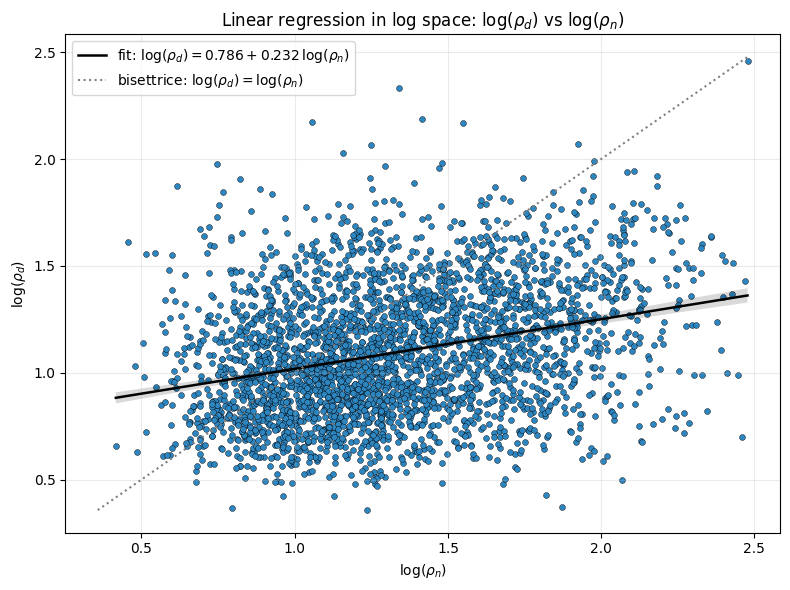

Numero complessi usati nel plot: 3134
alpha = 0.786028
beta = 0.232329


In [8]:
from matplotlib.lines import Line2D

# Regressione lineare in scala log: log(rho_d) = alpha + beta * log(rho_n)
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness']]
    .mean()
)

rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')

plot_df_lr = pd.DataFrame(index=rough_pivot.index)
plot_df_lr['rho_n'] = rough_pivot.get('native')
plot_df_lr['rho_d'] = rough_pivot.get('decoy')
plot_df_lr = plot_df_lr.dropna(subset=['rho_n', 'rho_d']).copy()
plot_df_lr = plot_df_lr[(plot_df_lr['rho_n'] > 0) & (plot_df_lr['rho_d'] > 0)].copy()

plot_df_lr['log_rho_n'] = np.log(plot_df_lr['rho_n'])
plot_df_lr['log_rho_d'] = np.log(plot_df_lr['rho_d'])

beta, alpha = np.polyfit(plot_df_lr['log_rho_n'], plot_df_lr['log_rho_d'], 1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df_lr,
    x='log_rho_n',
    y='log_rho_d',
    color='#2e86c1',
    s=18,
    edgecolor='black',
    linewidth=0.3,
    ax=ax,
)

sns.regplot(
    data=plot_df_lr,
    x='log_rho_n',
    y='log_rho_d',
    scatter=False,
    ax=ax,
    color='black',
    line_kws={'linewidth': 1.8},
)

line_min = min(plot_df_lr['log_rho_n'].min(), plot_df_lr['log_rho_d'].min())
line_max = max(plot_df_lr['log_rho_n'].max(), plot_df_lr['log_rho_d'].max())
ax.plot([line_min, line_max], [line_min, line_max], color='gray', linestyle=':', linewidth=1.5)

fit_handle = Line2D(
    [0], [0],
    color='black',
    linewidth=1.8,
    label=fr'fit: $\log(\rho_d)={alpha:.3f}+{beta:.3f}\,\log(\rho_n)$'
)
bisector_handle = Line2D(
    [0], [0],
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label=r'bisettrice: $\log(\rho_d)=\log(\rho_n)$'
)

ax.legend(handles=[fit_handle, bisector_handle], loc='best')
ax.set_xlabel(r'$\log(\rho_n)$')
ax.set_ylabel(r'$\log(\rho_d)$')
ax.set_title(r'Linear regression in log space: $\log(\rho_d)$ vs $\log(\rho_n)$')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Numero complessi usati nel plot:', len(plot_df_lr))
print(f'alpha = {alpha:.6f}')
print(f'beta = {beta:.6f}')

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


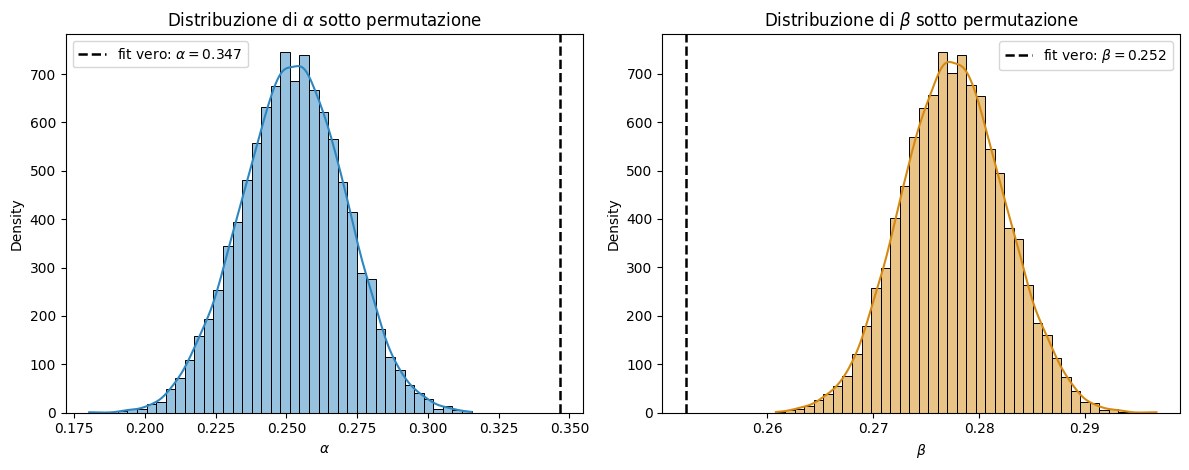

Numero complessi usati nel test: 3134
alpha vero = 0.346571
beta vero = 0.252327
alpha permutati: media=0.252494, std=0.018390
beta permutati: media=0.277596, std=0.004866


In [9]:
from matplotlib.lines import Line2D

# Test di permutazione per il fit della cella 7: rho_n / rho_d vs rho_n
# All'interno di ciascun terzile permuto a caso le roughness dei decoy
# e rifaccio il fit lineare 1000 volte, senza plottare i singoli fit.

rng = np.random.default_rng(42)
n_permutations = 10000

# Ricavo il dataset di lavoro della cella 7 in modo autosufficiente
paired = (
    tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['roughness']]
    .mean()
)
rough_pivot = paired.pivot(index='complex_name', columns='dataset_label', values='roughness')

perm_df = pd.DataFrame(index=rough_pivot.index)
perm_df['rho_n'] = rough_pivot.get('native')
perm_df['rho_d'] = rough_pivot.get('decoy')
perm_df = perm_df.dropna(subset=['rho_n', 'rho_d']).copy()
perm_df = perm_df[(perm_df['rho_n'] > 0) & (perm_df['rho_d'] > 0)].copy()

q_low, q_high = perm_df['rho_n'].quantile([1/3, 2/3])
perm_df['size_class'] = pd.cut(
    perm_df['rho_n'],
    bins=[-np.inf, q_low, q_high, np.inf],
    labels=['low', 'medium', 'large']
)

# Fit vero della cella 7, usato come riferimento: rho_n / rho_d = alpha + beta * rho_n
true_beta, true_alpha = np.polyfit(perm_df['rho_n'], perm_df['rho_n'] / perm_df['rho_d'], 1)

perm_alphas = []
perm_betas = []

for _ in range(n_permutations):
    permuted = perm_df.copy()

    # Permuto i decoy solo dentro ciascun terzile della riga native
    for cls in ['low', 'medium', 'large']:
        cls_mask = permuted['size_class'] == cls
        idx = permuted.index[cls_mask]
        if len(idx) == 0:
            continue
        permuted.loc[idx, 'rho_d'] = rng.permutation(permuted.loc[idx, 'rho_d'].to_numpy())

    x = permuted['rho_n'].to_numpy()
    y = (permuted['rho_n'] / permuted['rho_d']).to_numpy()
    beta_perm, alpha_perm = np.polyfit(x, y, 1)
    perm_alphas.append(alpha_perm)
    perm_betas.append(beta_perm)

perm_alphas = np.asarray(perm_alphas)
perm_betas = np.asarray(perm_betas)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.histplot(perm_alphas, bins=40, kde=True, color='#2e86c1', ax=axes[0])
axes[0].axvline(true_alpha, color='black', linestyle='--', linewidth=1.8, label=fr'fit vero: $\alpha={true_alpha:.3f}$')
axes[0].set_title(r'Distribuzione di $\alpha$ sotto permutazione')
axes[0].set_xlabel(r'$\alpha$')
axes[0].set_ylabel('Density')
axes[0].legend(loc='best')

sns.histplot(perm_betas, bins=40, kde=True, color='#d68910', ax=axes[1])
axes[1].axvline(true_beta, color='black', linestyle='--', linewidth=1.8, label=fr'fit vero: $\beta={true_beta:.3f}$')
axes[1].set_title(r'Distribuzione di $\beta$ sotto permutazione')
axes[1].set_xlabel(r'$\beta$')
axes[1].set_ylabel('Density')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

print('Numero complessi usati nel test:', len(perm_df))
print(f'alpha vero = {true_alpha:.6f}')
print(f'beta vero = {true_beta:.6f}')
print(f'alpha permutati: media={perm_alphas.mean():.6f}, std={perm_alphas.std(ddof=1):.6f}')
print(f'beta permutati: media={perm_betas.mean():.6f}, std={perm_betas.std(ddof=1):.6f}')